In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import os

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 10.5
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['xtick.labelsize'] = 9.5
plt.rcParams['ytick.labelsize'] = 9.5
plt.rcParams['legend.fontsize'] = 8.5
plt.rcParams['figure.titlesize'] = 12
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['axes.linewidth'] = 0.8
csv_file = "../../logs/log{}.csv"


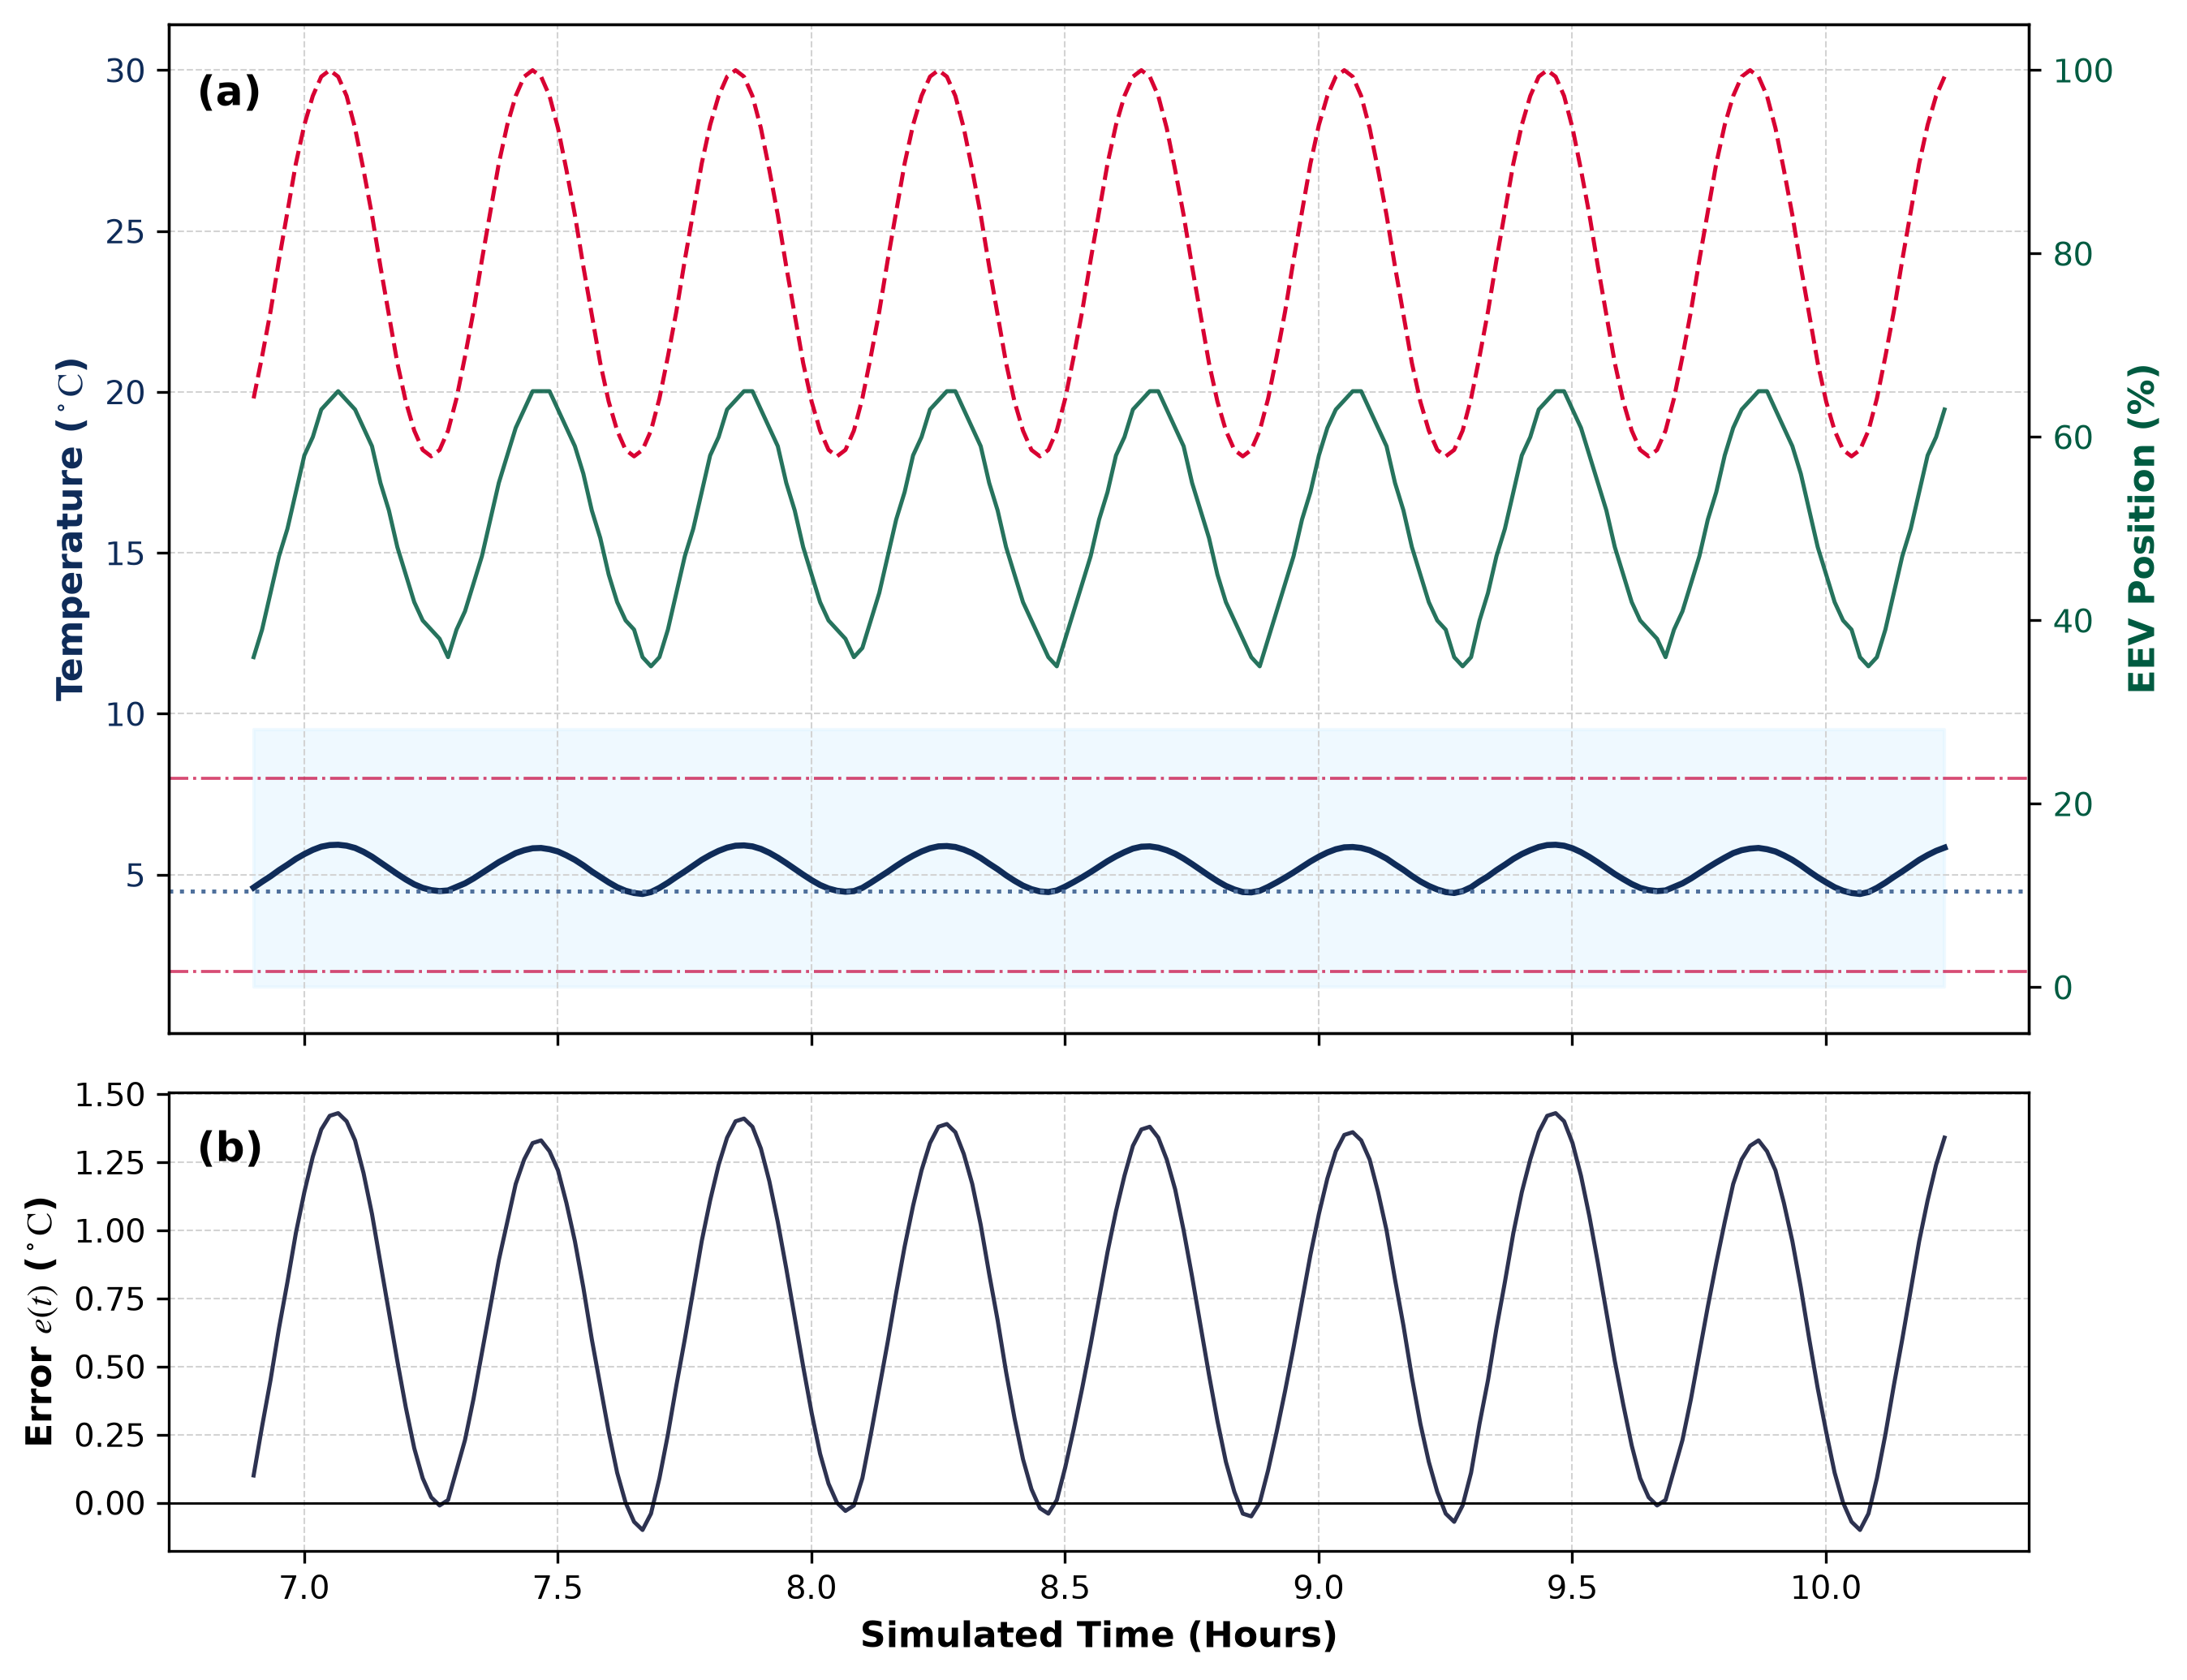

In [ ]:
df = pd.read_csv(csv_file.format("10"))
df['timestamp_ms'] = pd.to_numeric(df["timestamp_ms"], errors='coerce')
df = df.dropna(subset=['timestamp_ms'])

numeric_cols = ['room_temp', 'ambient_temp', 'valve_pct', 'power_mW', 'energy_mWh', 'leak_alert', 'cooling']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df['time_hours'] = (df["timestamp_ms"] - df['timestamp_ms'].iloc[0]) / 1000.0
df['time_hours'] = df['time_hours'].loc[400:600]
c_int = '#0F2C59'
c_amb = '#D80032'
c_valve = '#005B41'
c_alert = '#C70039'
c_fill = '#E0F4FF'

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7), sharex=True, gridspec_kw={'height_ratios': [2.2, 1]})

ax1.plot((df['time_hours']), df['room_temp'], color=c_int, lw=1.8, label=r'Internal Temp ($T_{\mathrm{int}}$)')
ax1.plot(df['time_hours'], df['ambient_temp'], color=c_amb, lw=1.2, ls='--', label=r'Ambient Temp ($T_{\mathrm{amb}}$)')
ax1.axhline(y=4.5, color='#4F709C', ls=':', lw=1.2, label=r'Target Setpoint ($T_{\mathrm{set}} = 4.5\,^\circ\mathrm{C}$)')
ax1.axhline(y=8.0, color=c_alert, ls='-.', lw=0.9, alpha=0.7, label=r'Upper Limit ($8.0\,^\circ\mathrm{C}$)')
ax1.axhline(y=2.0, color=c_alert, ls='-.', lw=0.9, alpha=0.7)

ax1.fill_between(df['time_hours'], 1.5, 9.5, where=(df["cooling"] == 1), color=c_fill, alpha=0.5)

leaks = df[df["leak_alert"] == 1]
if not leaks.empty:
    ax1.scatter(leaks['time_hours'], leaks['room_temp'], color=c_alert, marker='^', s=45, zorder=5, label='Insulation Leak Event')

ax1_sub = ax1.twinx()
ax1_sub.plot(df['time_hours'], df['valve_pct'], color=c_valve, lw=1.2, alpha=0.85, label='EEV Opening (%)')
ax1_sub.set_ylabel('EEV Position (%)', color=c_valve, fontweight='bold')
ax1_sub.tick_params(axis='y', labelcolor=c_valve)
ax1_sub.set_ylim(-5, 105)

ax1.set_ylabel(r'Temperature ($^\circ\mathrm{C}$)', color=c_int, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=c_int)
# ax1.set_ylim(1.5, 9.5)
ax1.grid(True, linestyle='--', linewidth=0.5, color='#D3D3D3')

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax1_sub.get_legend_handles_labels()
handles1.append(Patch(color=c_fill, alpha=0.6, label='Active Cooling'))
labels1.append('Active Cooling')
# ax1.legend(handles=handles1 + handles2, labels=labels1 + labels2, loc='upper right', framealpha=0.95, edgecolor='#CCCCCC', facecolor='white')
ax1.text(0.015, 0.92, '(a)', transform=ax1.transAxes, fontsize=12, fontweight='bold')

df['error'] = df['room_temp'] - 4.5
ax2.plot(df['time_hours'], df['error'], color='#2D3250', lw=1.2)
ax2.axhline(y=0, color='black', ls='-', lw=0.7)
ax2.set_xlabel('Simulated Time (Hours)', fontweight='bold')
ax2.set_ylabel(r'Error $e(t)$ ($^\circ\mathrm{C}$)', fontweight='bold')
ax2.grid(True, linestyle='--', linewidth=0.5, color='#D3D3D3')
ax2.text(0.015, 0.85, '(b)', transform=ax2.transAxes, fontsize=12, fontweight='bold')

plt.tight_layout()
os.makedirs("../../rapport/media", exist_ok=True)
plt.savefig("../../rapport/media/thermal_dynamics_research.png", dpi=300, bbox_inches='tight')
plt.savefig("../../rapport/media/simulation_results.png", dpi=300, bbox_inches='tight')
plt.show()


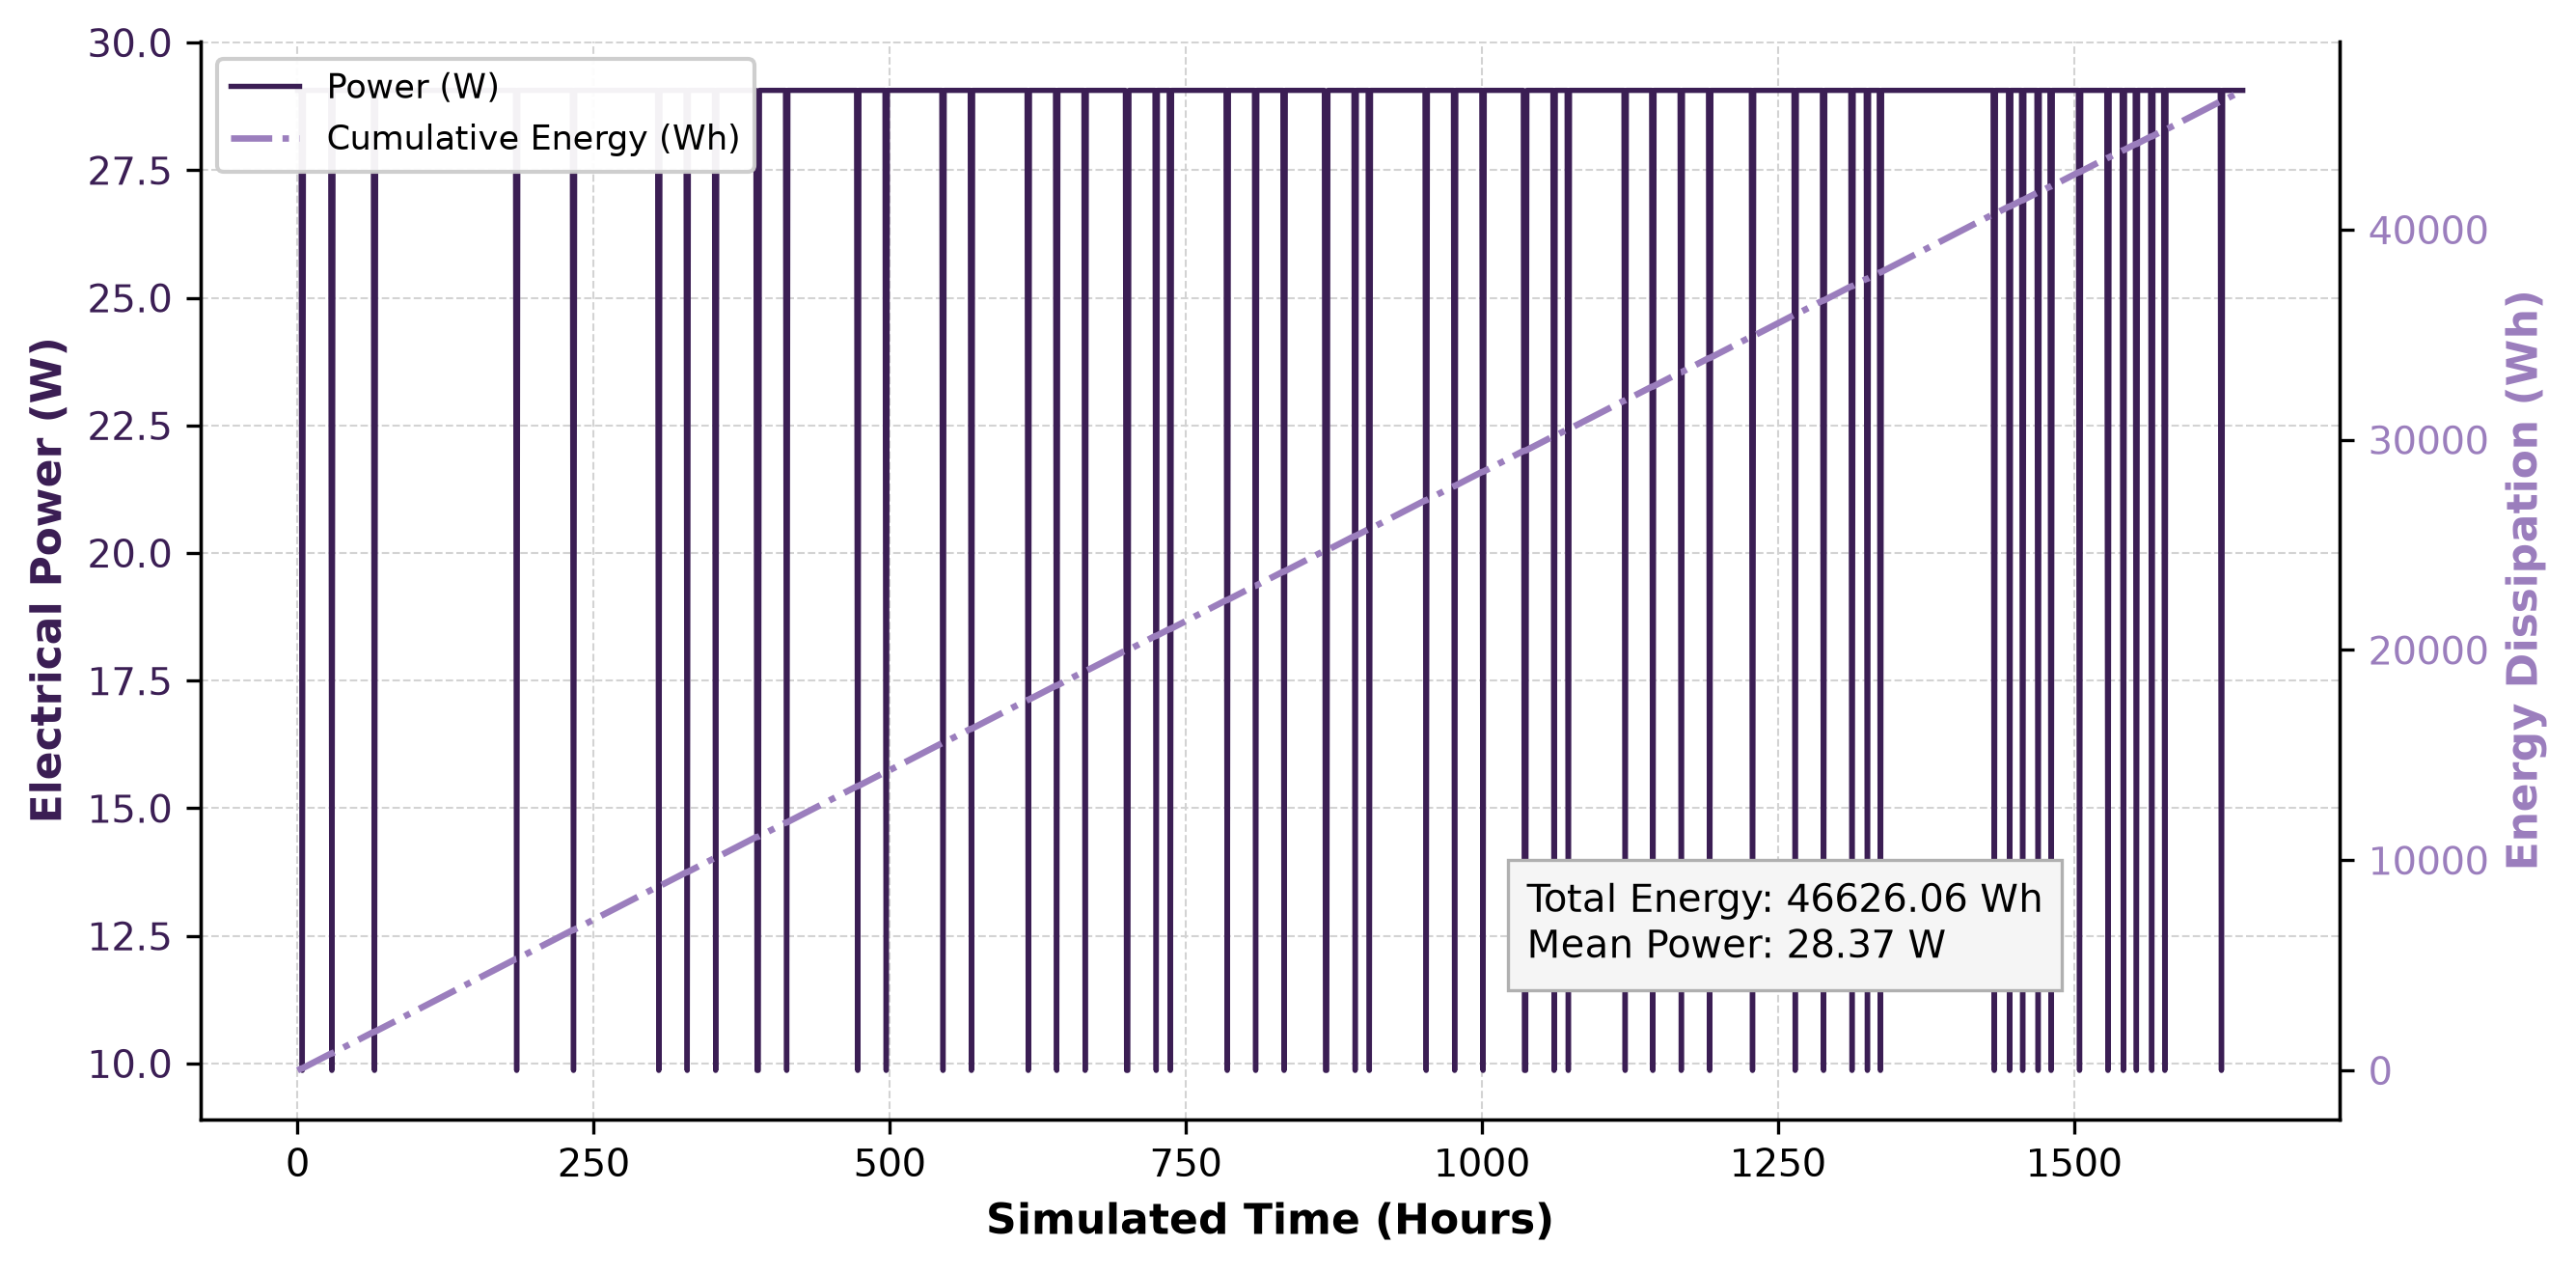

In [46]:
c_pwr = '#3B1E54'
c_eng = '#9B7EBD'

fig, ax1 = plt.subplots(figsize=(9, 4.5))

line1 = ax1.plot(df['time_hours'], df['power_mW'] / 1000.0, color=c_pwr, lw=1.3, label='Power (W)')
ax1.set_xlabel('Simulated Time (Hours)', fontweight='bold')
ax1.set_ylabel('Electrical Power (W)', color=c_pwr, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=c_pwr)
ax1.grid(True, linestyle='--', linewidth=0.5, color='#D3D3D3')

ax2 = ax1.twinx()
line2 = ax2.plot(df['time_hours'], df['energy_mWh'] / 1000.0, color=c_eng, lw=1.6, ls='-.', label='Cumulative Energy (Wh)')
ax2.set_ylabel('Energy Dissipation (Wh)', color=c_eng, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=c_eng)

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', framealpha=0.95, edgecolor='#CCCCCC')

tot_e = df['energy_mWh'].max() / 1000.0
mean_p = (df['power_mW'] / 1000.0).mean()
ax1.text(0.62, 0.15, f'Total Energy: {tot_e:.2f} Wh\nMean Power: {mean_p:.2f} W', transform=ax1.transAxes, fontsize=9.5, bbox=dict(boxstyle='square,pad=0.5', facecolor='#F5F5F5', edgecolor='#B0B0B0', lw=0.8))

for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)

plt.tight_layout()
plt.savefig("../../rapport/media/power_energy_research.png", dpi=300, bbox_inches='tight')
plt.show()


In [65]:
print((df['time_hours']).iloc[-1])

nan
